# What is a markovian walk?
A Markovian walk, also known as a Markov chain or random walk, is a mathematical model that describes a sequence of possible events in which the probability of each event depends only on the state attained in the previous event. In other words, it is a stochastic process that satisfies the Markov property, meaning that the future state of the process is independent of its past states, given its present state. It is only dependent on the current state and not on how it arrived at that state.

In [181]:
import matplotlib.pyplot as plt
import numpy as np
import random as rd
import pandas as pd

In [182]:
# initializing a grid 
line_1 = np.arange(start=0, stop=2, step=0.001)
line_1_grid = np.column_stack([line_1, np.zeros_like(line_1)])
line_2_grid = np.column_stack([line_1, np.full_like(line_1, 2)])
line_3_grid = np.vstack([np.full_like(line_1, 0), line_1])
line_4_grid = np.vstack([np.full_like(line_1, 2), line_1])
line_5_grid = np.vstack([np.full_like(line_1, 1), line_1])
line_6_grid = np.column_stack([line_1, np.full_like(line_1, 1)])

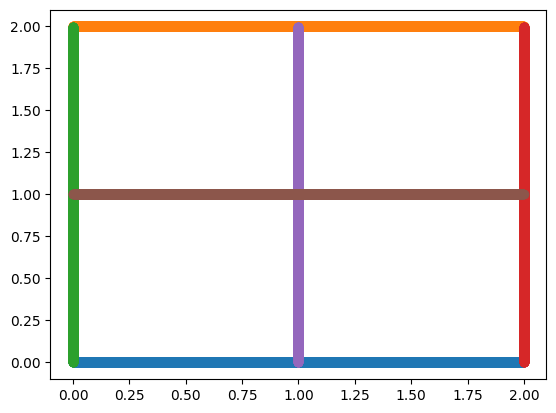

In [183]:
plt.scatter(line_1_grid[:, 0], line_1_grid[:, 1])
plt.scatter(line_2_grid[:, 0], line_2_grid[:, 1])
plt.scatter(line_3_grid[0, :], line_3_grid[1, :])
plt.scatter(line_4_grid[0, :], line_4_grid[1, :])
plt.scatter(line_5_grid[0, :], line_5_grid[1, :])
plt.scatter(line_6_grid[:, 0], line_6_grid[:, 1])
plt.show()

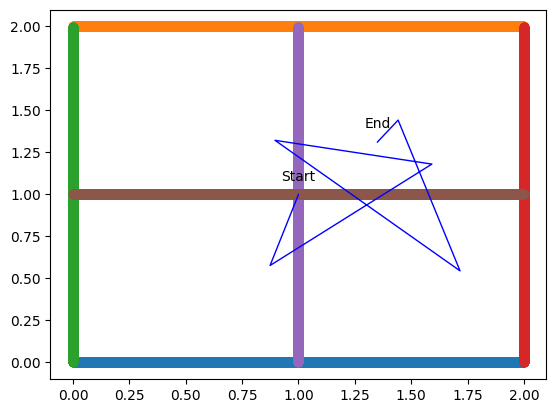

In [184]:
# creating the point that moves along the grid

seed = 20000
rd.seed(seed)
x = np.array([1.0, 1.0])
DEV_NOISE = 1
dev = np.array([rd.uniform(-DEV_NOISE, DEV_NOISE), rd.uniform(-DEV_NOISE, DEV_NOISE)])
n=0
plt.scatter(line_1_grid[:, 0], line_1_grid[:, 1])
plt.scatter(line_2_grid[:, 0], line_2_grid[:, 1])
plt.scatter(line_3_grid[0, :], line_3_grid[1, :])
plt.scatter(line_4_grid[0, :], line_4_grid[1, :])
plt.scatter(line_5_grid[0, :], line_5_grid[1, :])
plt.scatter(line_6_grid[:, 0], line_6_grid[:, 1])
x_history = []
y_history = []
while (0 < x[0] < 2) and (0 < x[1] < 2):
    # save current position
    x_history.append(x[0])
    y_history.append(x[1])
    # take next step
    x = x + dev
    dev = np.array([rd.uniform(-DEV_NOISE, DEV_NOISE), rd.uniform(-DEV_NOISE, DEV_NOISE)])
plt.plot(x_history, y_history, color='blue', linewidth=1)
plt.scatter(x_history, y_history, color='red', s=0.0001)
plt.annotate('Start', (x_history[0], y_history[0]), textcoords="offset points", xytext=(0, 10), ha='center')
plt.annotate('End', (x_history[-1], y_history[-1]), textcoords="offset points", xytext=(0, 10), ha='center')
plt.show()

# Deviation or Coordinate based memory?

We will now try to implement short-range memory into the system. We will do this by introducing a parameter called ``memory_extent``. This parameter will determine how many previous states the system will consider when making a decision about the next state.
We will also introduce an array called ``memory_weights`` which will decide how much weight each previous state will have in the decision-making process. The weights will be normalized so that they sum to 1, ensuring that the probabilities of transitioning to the next state remain valid.
Next, we are going to make another array called ``memory_states`` which will store the previous states of the system. The length of this array will be equal to ``memory_extent``. When the system transitions to a new state, the oldest state in the ``memory_states`` array will be removed, and the new state will be added to the end of the array.

We also need to consider if our system is going to be based on deviation or coordinates. If we are using deviation, we will calculate the deviation of the current state from the previous states and use that to determine the next state. If we are using coordinates, we will use the actual coordinates of the previous states to determine the next state.

## Coordinate based memory

We will have to think of the function we are going to use to determine the next state based on the previous states. For now, we are going to use a simple average of the previous states to determine the next state. This means that the next state will be the average of the previous states, weighted by their respective weights in the ``memory_weights`` array.

In [192]:
# defining the parameters for the memory-based system

MEMORY_EXTENT = 5
MEMORY_WEIGHTS = np.arange(start=1, stop=0.001, step=-1/MEMORY_EXTENT)
MEMORY_STATES = []

In [191]:
# deploying the memory-based system
def memory_walk(x, memory_extent, memory_states, memory_weights, dev_noise, max_points, seed):
    rd.seed(seed)
    n = 0
    x_history = []
    y_history = []
    while (0 < x[0] < 2) and (0 < x[1] < 2):
        # check if we have enough memory states
        if len(memory_states) < memory_extent:
            # if not, just take a random step
            x_history.append(x[0])
            y_history.append(x[1])
            dev = np.array([rd.uniform(-dev_noise, dev_noise), rd.uniform(-dev_noise, dev_noise)])
            x = x + dev
            memory_states.append(x.copy())
        else:
            # if we have enough memory states, calculate the weighted average of the previous states
            x_history.append(x[0])
            y_history.append(x[1])
            weighted_average = np.average(memory_states, axis=0, weights=memory_weights)
            # take a step towards the weighted average
            dev = weighted_average - x
            x = x + dev
            memory_states.append(x.copy())
            memory_states.pop(0)  # remove the oldest state to maintain the memory extent
        n = n + 1
        if n % 10 == 0:
            print(f"Step {n}: Current position: {x}")
        if n > max_points:  # safety break to prevent infinite loops
            print("Reached maximum number of steps.")
            break
    plt.scatter(line_1_grid[:, 0], line_1_grid[:, 1])
    plt.scatter(line_2_grid[:, 0], line_2_grid[:, 1])
    plt.scatter(line_3_grid[0, :], line_3_grid[1, :])
    plt.scatter(line_4_grid[0, :], line_4_grid[1, :])
    plt.plot(x_history, y_history, color='blue', linewidth=1)
    plt.scatter(x_history[:memory_extent], y_history[:memory_extent], color='blue', s=10)
    plt.scatter(x_history[memory_extent:], y_history[memory_extent:], color='red', s=10)
    plt.annotate('Start', (x_history[0], y_history[0]), textcoords="offset points", xytext=(0, 10), ha='center')
    plt.annotate('End', (x_history[-1], y_history[-1]), textcoords="offset points", xytext=(0, 10), ha='center')
    plt.show()
    print(f"Total steps taken: {n}")

Step 10: Current position: [1.35472252 1.16204201]
Step 20: Current position: [1.3603802  1.07116495]
Step 30: Current position: [1.36527697 1.06654516]
Step 40: Current position: [1.36561051 1.06652204]
Step 50: Current position: [1.36559907 1.0665382 ]
Reached maximum number of steps.


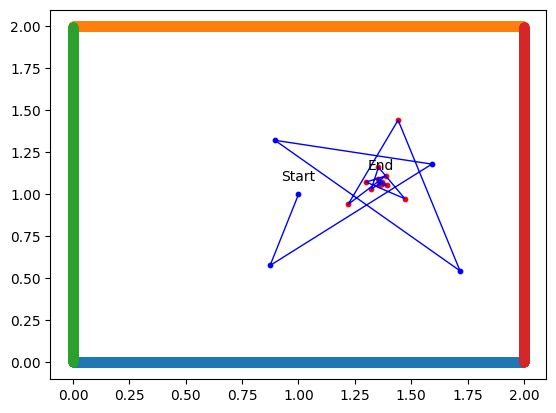

Total steps taken: 51


In [193]:
memory_walk(np.array([1.0, 1.0]), MEMORY_EXTENT, MEMORY_STATES, MEMORY_WEIGHTS, 1, 50, 20000)